[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/misc/Gedzelman_and_Arnold_1994/fig_2.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/misc/Gedzelman_and_Arnold_1994/fig_2.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/misc/Gedzelman_and_Arnold_1994/fig_2.ipynb)

#### based on Fig. 2 from Gedzelman and Arnold 1994 (JGR)  "_Modeling the isotopic composition of precipitation_"
https://doi.org/10.1029/93JD03518

**Description**  
Theoretical curves from the paper are reproduced as in Fig. 2, separately for liquid and vapour isotopic content. The figure illustrates the change in Deuterium isotopic composition in both liquid and vapour phases following an arbitrary water mass change, relative to the theoretical lines.

**Notes**  
- Parameter *b* in Eq. (18) of the paper appears to be missing a multiplication by $\rho_\text{s}$. Including $\rho_\text{s}$ corrects the units and aligns the reproduced plot with expectations. This suggests a likely typographical error in the original equation.

**Extensions (see plots in the second section)**  
- Support for multiple isotopes: D, $^{18}$O, $^{17}$O  
- Modern parameterizations:  
  - Horita & Wesolowski (1994) for D and $^{18}$O equilibrium fractionation  
  - Barkan & Luz (2005) for $^{17}$O fractionation  
  - Hellmann & Harvey (2020) for diffusivities  
- Environmental isotope ratio plotted on axis for comparison  
- Explicit temperature dependence in fractionation calculations 

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [2]:
from collections import namedtuple
import numpy as np
from matplotlib import pyplot
from matplotlib.lines import Line2D
from open_atmos_jupyter_utils import show_plot

from PySDM import Formulae
from PySDM.physics.constants import si, PER_MILLE, in_unit, PER_CENT

#### derivations:

- Maxwell-Mason equation (introducing $\rho_\text{s}=\frac{p_\text{vs}}{R_\text{v}T}$, approximated for $S_\text{eq}\approx 1$ and taking into account $\frac{l_\text{v}}{R_\text{v} T} \approx 20 \gg 1$):
$$
a\frac{da}{dt} 
= f \frac{
    S - S_\text{eq}
}{
    \rho_w \left(
        \frac{R_\text{v} T }{\Psi p_\text{vs}(T)} + 
        \frac{l_\text{v}}{K T} \left(\frac{l_\text{v}}{R_\text{v} T}-1\right)
    \right)
}
\approx \frac{f}{\rho_\text{w}} \frac{S - 1}{        \frac{1}{\Psi \rho_\text{s}} + 
        \frac{l^2_\text{v}}{K R_v T^2}
}
= \frac{f \Psi \rho_\text{s}}{\rho_\text{w}} \frac{S - 1}{        1 + 
        \frac{\Psi \rho_\text{s} l^2_\text{v}}{K R_v T^2}
}
$$
where $t$ is time, $a$ is drop radius, $f$ is ventilation factor, $\Psi$ is mass diffusion coefficient, $K$ thermal diffusion coefficient, $l_\text{v}$ is latent heat of condensation, $R_\text{v}$ gas constant for water vapour, $T$ temperature, $\rho_\text{w}$ density of water, $\rho_\text{s}$ saturation vapour density.

In [3]:
CONST = Formulae().constants
print(f"lv/(Rv T) at the triple point: {CONST.l_tri / (CONST.Rv * CONST.T_tri):.3g}")
CONST = None

lv/(Rv T) at the triple point: 19.8


- expressed in terms of mass $m=\frac{4}{3}\pi a^3 \rho_\text{w}$:

$$\frac{dm}{dt} / [\text{surface}]
= \frac{d\left(\frac{4}{3}\pi a^3 \rho_\text{w}\right)}{dt} \frac{1}{4 \pi a^2}
= \rho_\text{w} \frac{da}{dt}
$$

- introducing $b=\frac{l^2_\text{v} \Psi}{K R_\text{v}T^2}$ and approximating leads to eq. (16) in the paper:

$$
\frac{dm}{dt} 
\approx 4 \pi a \Psi f \rho_\text{s}\frac{S-1}{1 + b \rho_\text{s}}
$$

 Note that $b \rho_\text{s}$ from the denominator can be rewritten using $F_d$ and $F_k$ (notation from [Rogers & Yau 1989](https://archive.org/details/shortcourseinclo0000roge_m3k2)):
$$F_d = \rho_\text{w}  \frac{R\text{v}  T}{\Psi p_\text{vs}} = \frac{\rho_\text{w}}{\Psi \rho_\text{s}}, \quad F_k = \rho_\text{w}  \frac{l_\text{v}^2 }{ T^2  K  R_\text{v}},$$
resulting in 
$$
b \rho_\text{s} = \frac{l^2_\text{v} \Psi}{K R_\text{v}T^2} \rho_\text{s} = \frac{\rho_\text{w}  \frac{l_\text{v}^2 }{ T^2  K  R_\text{v}}}{ \rho_\text{w}\frac{1}{\Psi \rho_\text{s}}} =   F_k / F_d.
$$

In [4]:
IsotopeContext = namedtuple("IsotopeContext", ["iso", "T"])
Parameters = namedtuple(
    "params", [
        "D_ratio_heavy_to_light",
        "alpha_w",
        "Fk_plus_Fd",
        "b",
        "vsmow",
    ]
)
Commons = namedtuple("Commons", ["f", "c", "iso", "T", "params"])

class CommonsFactory: #pylint: disable=too-few-public-methods
    """Compute and assemble common isotope quantities."""
    def __init__(self, formulae):
        self._f = formulae
        self._const = formulae.constants

    def build(self, ctx: IsotopeContext):
        """build factory"""
        return Commons(
            f=self._f,
            c=self._const,
            iso=ctx.iso,
            T=ctx.T,
            params=self._build_params(ctx),
        )

    def _build_params(self, ctx):
        """Calculate parameters from formulae"""
        vsmow = getattr(self._const, f"VSMOW_R_{ctx.iso}")
        diff_fun = getattr(
            self._f.isotope_diffusivity_ratios,
            f"ratio_{ctx.iso}_heavy_to_light",
        )
        f_ratio_heavy_to_light = 1 # Ventilation effects neglected (no droplet-radius dependence)
        D_ratio_heavy_to_light = diff_fun(ctx.T) * f_ratio_heavy_to_light
        pvs = self._f.saturation_vapour_pressure.pvs_water(ctx.T)
        fk = self._f.drop_growth.Fk(
            T=ctx.T,
            K=self._const.K0,
            lv=self._f.latent_heat_vapourisation.lv(ctx.T),
        )
        fd = self._f.drop_growth.Fd(
            pvs=pvs,
            T=ctx.T,
            D=self._const.D0,
        )
        return Parameters(
            D_ratio_heavy_to_light=D_ratio_heavy_to_light,
            alpha_w=self._alpha_w(ctx),
            Fk_plus_Fd=fk + fd,
            b=fk / fd,
            vsmow=vsmow,
        )
    
    def _alpha_w(self, ctx: IsotopeContext) -> float:
        """Calculate isotopic fractionation factor for specified isotope"""
        alpha_fun = getattr(
            self._f.isotope_equilibrium_fractionation_factors,
            f'alpha_l_{ctx.iso}',
        )
        if ctx.iso == '17O':
            alpha_l_18o = (
                self._f.isotope_equilibrium_fractionation_factors.alpha_l_18O(
                    ctx.T
                )
            )
            return alpha_fun(np.nan, alpha_l_18o)
        return alpha_fun(ctx.T)
    
C2K = Formulae().trivia.C2K

In [5]:
def no_fractionation_saturation(iso_ratio_over_vsmow, iso_ratio_vap, commons, water_phase):
    """
    Wrapper for saturation_for_zero_dR_condition formula
    utilising precomputed parameters from commons
    """
    iso_ratio_liq = iso_ratio_over_vsmow * commons.params.vsmow
    return commons.f.isotope_ratio_evolution.saturation_for_zero_dR_condition(
        iso_ratio_x=iso_ratio_liq if water_phase=='liquid' else iso_ratio_vap,
        diff_rat_light_to_heavy=1 / commons.params.D_ratio_heavy_to_light,
        b=commons.params.b,
        alpha_w=commons.params.alpha_w,
        iso_ratio_r=iso_ratio_liq,
        iso_ratio_v=iso_ratio_vap,
    )

In [6]:
class Paper: #pylint: disable=too-few-public-methods
    """Configuration reproducing the paper setup. Instance is not needed."""
    formulae = Formulae(
        isotope_equilibrium_fractionation_factors="MerlivatAndNief1967+Majoube1971",
        isotope_kinetic_fractionation_factors="JouzelAndMerlivat1984",
        isotope_relaxation_timescale="ZabaEtAl",
        isotope_diffusivity_ratios="Stewart1975",
        isotope_ratio_evolution="GedzelmanAndArnold1994",
        isotope_ventilation_ratio="Neglect",  # droplet-size dependent, ignored here
        drop_growth="Mason1971",
    )
    isotope = "2H"
    delta_v = -200 * PER_MILLE
    temperature = C2K(10.0) * si.K
    xlim = (0.8, 1.05)
    rh_lim = (0.0, 1.05)
    rh_unit = PER_CENT

In [7]:
cmn = CommonsFactory(Paper.formulae).build(
    IsotopeContext(iso=Paper.isotope, T=Paper.temperature)
)
CMN_FOR_TEST = cmn

In [8]:
RH = np.linspace(0.01, 1.1, 32)
R_liq_over_vsmow = np.linspace(*Paper.xlim, 32)

XX, YY = np.meshgrid(R_liq_over_vsmow, RH)

T = cmn.T
rho_v = cmn.f.saturation_vapour_pressure.pvs_water(cmn.T) / cmn.T / cmn.c.Rv
Fk = cmn.f.drop_growth.Fk(T=cmn.T, K=cmn.c.K0, lv=cmn.c.l_tri)
Fd = cmn.f.drop_growth.Fd(T=cmn.T, D=cmn.c.D0, pvs=cmn.f.saturation_vapour_pressure.pvs_water(cmn.T))

ISO_RATIO_V = cmn.f.trivia.isotopic_delta_2_ratio(Paper.delta_v, cmn.params.vsmow)
X_eq = ISO_RATIO_V * cmn.params.alpha_w / cmn.params.vsmow
Y_eq = in_unit(1, Paper.rh_unit)
Bolin_number = cmn.f.isotope_relaxation_timescale.bolin_number(
    D_ratio_heavy_to_light=cmn.params.D_ratio_heavy_to_light,
    alpha=cmn.params.alpha_w,
    Fd=Fd,
    Fk=Fk,
    R_vap=ISO_RATIO_V,
    R_liq=XX * cmn.params.vsmow,
    relative_humidity=YY,
)

In [9]:
cases = {
    "liquid": {
        "eqs": Bolin_number,
        "label": "$\\bf{{(A)}}$ Bolin number $\\left(\\text{Bo}=\\frac{\\tau_\\text{heavy}}{\\tau_\\text{total}}\\right)$ [1]",
        "center": 1,
        "linestyle": "-",
    },
    "vapour": {
        "eqs":  XX * cmn.params.vsmow / ISO_RATIO_V - Bolin_number,
        "label": "$\\bf{{(B)}}$ "
                 + "$\\frac{\\text{R}_\\text{liq}}{\\text{R}_\\text{vap}} - \\text{Bo}$ [1]",
        "center": 0,
        "linestyle": "--",
    }
}
plots = {"liquid": {}, "vapour": {}}

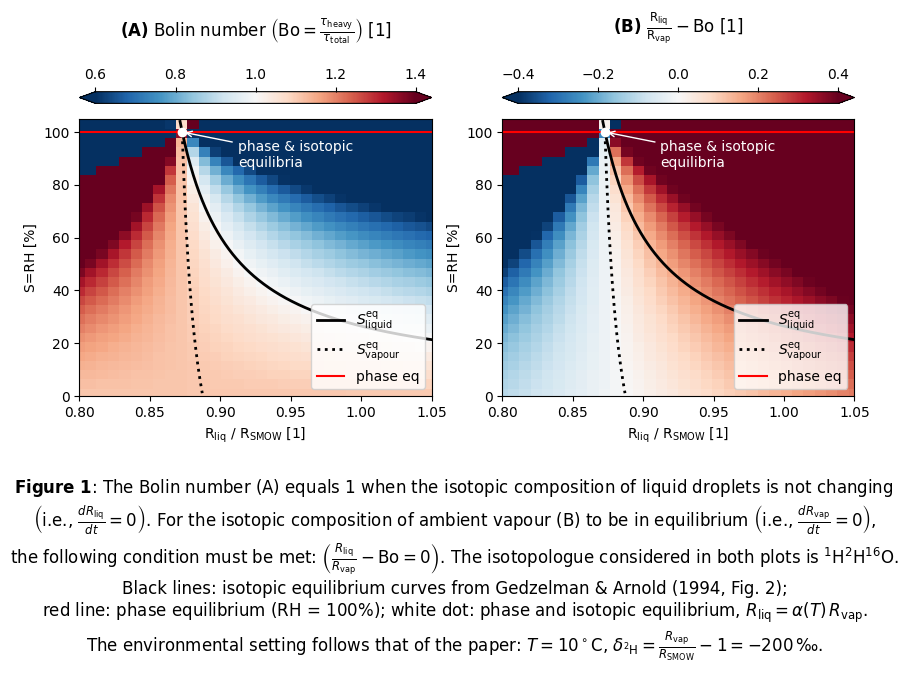

In [10]:
fig, axs = pyplot.subplots(
    1, 2,
    figsize=(10,4),
)
for i, (phase, params) in enumerate(cases.items()):
    pcm = axs[i].pcolormesh(R_liq_over_vsmow, in_unit(RH, Paper.rh_unit), params["eqs"],
                cmap='RdBu_r', vmin=-.4 + params['center'], vmax=.4 + params['center'])
    cases[phase]["pcolormesh"] = pcm
    cb = fig.colorbar(pcm, ax=axs[i], orientation='horizontal', location='top', aspect=30, fraction=0.05, extend='both')
    cb.set_label(f"{params['label']}\n", fontsize=12)
    
    for p in cases:
        x = np.linspace(0, 1.05, 2000)
        y = no_fractionation_saturation(x, ISO_RATIO_V, cmn, p)
        plots[p]["x"] = x
        plots[p]["y"] = y
        y_masked = np.where((0.0 < y) & (y < 1.05), y / PER_CENT, np.nan)
        axs[i].plot(
            x, y_masked,
            label=rf"$S_\text{{{p}}}^\text{{eq}}$",
            ls="-" if p[0] == 'l' else ":", lw=2, c='k',
        )
    
    axs[i].plot(R_liq_over_vsmow, np.full_like(R_liq_over_vsmow, Y_eq), c='r', label='phase eq')
    axs[i].annotate('phase & isotopic\nequilibria', xy=(X_eq, Y_eq), color='white',
        arrowprops={"arrowstyle": '->', "color": 'white', "lw": 1},
                    textcoords='offset points',xytext=(40, -25),)
    axs[i].scatter(X_eq, Y_eq, c='white', zorder=2.5)
    
for ax in axs:
    ax.set_xlabel("R$_\\text{liq}$ / R$_\\text{SMOW}$ [1]")
    ax.set_xlim(R_liq_over_vsmow[0], R_liq_over_vsmow[-1])
    ax.set_ylabel("S=RH [%]")
    ax.set_ylim(0, 105)
    ax.legend(loc="lower right")

text = rf"""$\mathbf{{Figure\ 1}}$: The Bolin number (A) equals 1 when the isotopic composition of liquid droplets is not changing 
$\left(\text{{i.e., }} \frac{{dR_{{\text{{liq}}}}}}{{dt}} = 0\right)$. For the isotopic composition of ambient vapour (B) to be in equilibrium $\left(\text{{i.e., }} \frac{{dR_{{\text{{vap}}}}}}{{dt}} = 0\right)$,
the following condition must be met: $\left(\frac{{R_{{\text{{liq}}}}}}{{R_{{\text{{vap}}}}}} - \text{{Bo}} = 0\right)$. The isotopologue considered in both plots is $^1\mathrm{{H}}^2\mathrm{{H}}^{{16}}\mathrm{{O}}$.
Black lines: isotopic equilibrium curves from Gedzelman & Arnold (1994, Fig. 2);
red line: phase equilibrium (RH = 100%); white dot: phase and isotopic equilibrium, $R_{{\text{{liq}}}} = \alpha(T)\,R_{{\text{{vap}}}}$.
The environmental setting follows that of the paper: $T = {Paper.temperature-273.15:.0f}^\circ\mathrm{{C}}$, $\delta_{{^2\mathrm{{H}}}} = \frac{{R_{{\text{{vap}}}}}}{{R_{{\text{{SMOW}}}}}} - 1 = {in_unit(Paper.delta_v, PER_MILLE):.0f}\,‰$.
"""
fig.text(0.5, -0.6, text, ha="center", fontsize=12)
show_plot("Bo", inline_format='png')

# Extensions

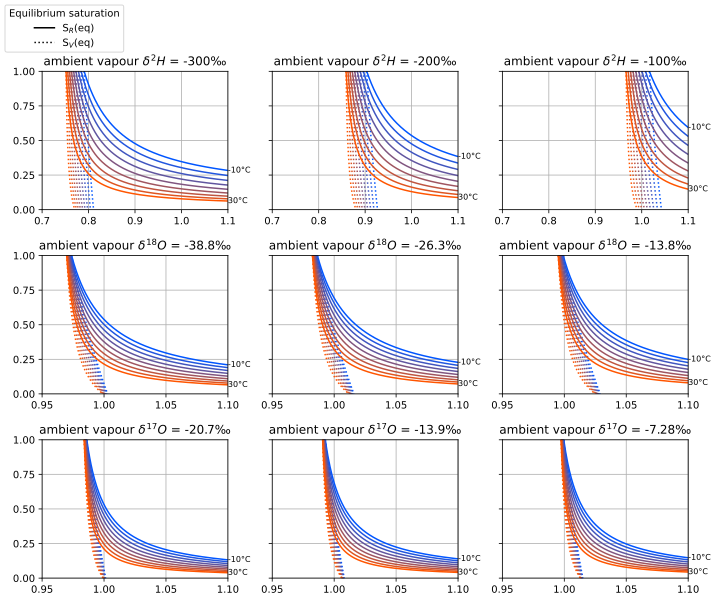

In [11]:
f = Formulae(
    isotope_equilibrium_fractionation_factors="BarkanAndLuz2005+HoritaAndWesolowski1994",
    isotope_diffusivity_ratios="HellmannAndHarvey2020",
    isotope_meteoric_water_line="BarkanAndLuz2007+Dansgaard1964",
    isotope_ratio_evolution="GedzelmanAndArnold1994",
    isotope_ventilation_ratio="Neglect",
)
commons_factory = CommonsFactory(f)

iso_mwl = f.isotope_meteoric_water_line
d2H = (-300, -200, -100)
deltas_2H = [x * PER_MILLE for x in d2H]
deltas_18O = [iso_mwl.d18O_of_d2H(d) for d in deltas_2H]
deltas_17O = [iso_mwl.d17O_of_d18O(d) for d in deltas_18O]

x_lim = {"2H": (0.7, 1.1), "18O": (0.95, 1.1), "17O": (0.95, 1.1)}

fig, axs = pyplot.subplots(3, 3, figsize=(10, 8), sharey=True)
Ts = np.linspace(C2K(-10.0) * si.K, C2K(30.0) * si.K, 9)
for idx_iso, iso in enumerate(("2H", "18O", "17O")):
    for j_delta, delta in enumerate((deltas_2H, deltas_18O, deltas_17O)[idx_iso]):
        ax = axs[idx_iso][j_delta]
        for t in Ts:
            cmn = commons_factory.build(IsotopeContext(iso, t))
            iso_ratio_v = cmn.f.trivia.isotopic_delta_2_ratio(delta, cmn.params.vsmow)
            x = np.linspace(
                cmn.params.alpha_w * iso_ratio_v  / cmn.params.vsmow, 1.1, 200
            )
            y_liq = no_fractionation_saturation(x, iso_ratio_v, cmn, 'liquid')
            y_vap = no_fractionation_saturation(x, iso_ratio_v, cmn, 'vapour')

            c = (
                (t - Ts[0]) / (Ts[-1] - Ts[0]),
                0.333,
                1 - (t - Ts[0]) / (Ts[-1] - Ts[0]),
            )
            if t in (Ts[0], Ts[-1]):
                ax.annotate(
                    f"{Formulae().trivia.K2C(t):g}°C",
                    (x_lim[iso][1], y_liq[-1] - 0.015),
                    fontsize=8
                )
            ax.plot(x, y_liq, c=c, ls="-")
            ax.plot(x, y_vap, c=c, ls=":")

        ax.set(
            title=f"ambient vapour $\\delta^{{{iso[:-1]}}}{iso[-1]}$ = {in_unit(delta, PER_MILLE):.3g}‰",
            xlim=x_lim[iso],
            ylim=(0, 1),
            yticks=np.linspace(0, 1, 5),
        )
        if j_delta != 0:
            ax.set_ylabel("")
        ax.grid(True)

legend_lines = [
    Line2D([0], [0], color="black", linestyle="-", label="S$_R$(eq)"),
    Line2D([0], [0], color="black", linestyle=":", label="S$_V$(eq)"),
]

fig.legend(
    legend_lines,
    [*[l.get_label() for l in legend_lines]],
    loc="upper left",
    title="Equilibrium saturation",
)
fig.tight_layout()
fig.subplots_adjust(top=0.88, bottom=0)
show_plot("plot_grid.pdf")